# Auditing physical evidence in laboratory automation logs

**Research question:** To what extent can software-level laboratory actions be traced to independent evidence of their physical execution?

This notebook is a concise view of results computed by the normal Python modules in `src/lab_log_audit/`. The authoritative non-notebook entry point is `scripts/reproduce.py`. Headline numbers below are read from `results/metrics.json` and `results/window_sensitivity.csv`.

## 1. Dataset and provenance

The audit uses the Flex-Cat v1 archive (Zenodo record 18930287) and two modalities from Batch Distillation 1.1.2 (Zenodo record 21535243). Raw archives are not committed. `data/manifest.json` pins names, sizes, hashes, releases, retrieval date, creators, and licences.

Code in this repository is MIT-licensed. Flex-Cat and Batch Distillation are third-party CC BY 4.0 datasets; the MIT licence does not relicense them. Flex-Cat CC BY 4.0 is taken from the Zenodo API `metadata.license.id` for record 18930287 (checked 2026-08-30).

## 2. Definitions

- **Action:** a software-level `type="operation"` event, or a labelled recovery in metadata.
- **Controller/readback:** a value whose controller or device origin is established. The source does not establish that semantic class for `actualVolume`.
- **Independent physical evidence:** an observation from a distinct physical channel sufficient to support an effect claim.
- **RecoveryLabel / RecoveryEvidence / RecoveryOutcome:** kept distinct. A metadata recovery label is not evidence, and evidence in the operation log is not a proven outcome.
- **Window match:** any operation-log row whose parseable time of day lies inside the declared inclusive window. This is an observability/activity proxy. It is not evidence that the labelled recovery action itself was observed. A silent window is not evidence that no intervention occurred.

In [1]:
import csv
import json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
metrics = json.loads((ROOT / "results" / "metrics.json").read_text(encoding="utf-8"))


def read_csv(name):
    with (ROOT / "results" / name).open(encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))


sensitivity = read_csv("window_sensitivity.csv")
null_variants = read_csv("background_null.csv")
batch = metrics["batch_distillation"]
inclusion = batch["inclusion"]
original = batch["original_window"]
background = batch["background_null"]
actions = metrics["chemspeed"]["actions"]
endpoints = metrics["chemspeed"]["transfer_endpoints"]
print(metrics["research_question"])
print()
print(batch["coverage_definition"])

To what extent can software-level laboratory actions be traced to independent evidence of their physical execution?

labelled recovery with at least one operation-log row whose parseable time of day lies in the inclusive window; observability/activity proxy, not evidence that the labelled recovery action itself was observed


## 3. Action-level audit

Identity is `(application_epoch, operationid)` for Chemspeed events with `type="operation"` only. Pairing is clean when that identity has exactly one start and one end.

In [2]:
clean = actions["clean"]
print(f"Operations parsed: {actions['total']}")
print(f"Clean pairs: {clean['numerator']} / {clean['denominator']}")
print("Pairing status counts:", actions["pairing_status_counts"])

Operations parsed: 986
Clean pairs: 986 / 986
Pairing status counts: {'clean': 986, 'count_mismatch': 0, 'duplicate_end': 0, 'duplicate_start': 0, 'missing_end': 0, 'missing_start': 0}


## 4. `actualVolume`

The comparison is exact decimal equality between requested `volume` and reported `actualVolume` on transfer endpoints that contain both fields. Equality does not establish an independent physical measurement, and it does not establish that the field is false.

In [3]:
equal = endpoints["reported_equals_requested"]
print(
    f"Endpoints with reported actualVolume: {endpoints['with_reported_actual_volume']}"
)
print(f"Incomplete endpoints skipped: {endpoints['skipped_incomplete_endpoints']}")
print(f"Reported equals requested: {equal['numerator']} / {equal['denominator']}")
print("Evidence class:", endpoints["evidence_class"])
print(
    "Independent physical measurement established:",
    endpoints["independent_physical_measurement_established"],
)

Endpoints with reported actualVolume: 60
Incomplete endpoints skipped: 0
Reported equals requested: 60 / 60
Evidence class: reported_value_semantics_unverified
Independent physical measurement established: False


## 5. Temporal evidence coverage

Two labelled recoveries are excluded because the pinned release has no operation log for that experiment. The coverage numerator counts included recoveries that have at least one parseable operation-log timestamp in the original inclusive window. That count is not a count of observed operator recoveries.

In [4]:
print(f"Metadata labelled recoveries: {inclusion['metadata_labelled_recoveries']}")
print(f"Excluded without operation log: {inclusion['excluded_without_operation_log']}")
print("Excluded records:", inclusion["excluded_source_records"])
print(f"Included with operation log: {inclusion['included_with_operation_log']}")
print(
    "Unparseable or empty event timestamps:",
    inclusion["unparseable_event_timestamps"],
)
print(
    f"Original window [-{original['pre_window_seconds']} s, +{original['post_window_seconds']} s]: "
    f"{original['matched_actions']} / {original['total_actions']} = {original['coverage']:.2%}"
)

Metadata labelled recoveries: 81
Excluded without operation log: 2
Excluded records: ['batch_dist_ternary_butan-1-ol+propan-2-ol+water/operating_point_014/test_anormal_experiment_002::OP014TA002A002', 'batch_dist_ternary_butan-1-ol+propan-2-ol+water/operating_point_014/test_anormal_experiment_002::OP014TA002A004']
Included with operation log: 79
Unparseable or empty event timestamps: 43
Original window [-60 s, +120 s]: 34 / 79 = 43.04%


## 6. Sensitivity analysis

Wider windows can include unrelated UI or process activity. The table is a robustness check, not causal attribution, and still does not identify recovery actions.

In [5]:
print("pre_s\tpost_s\tmatched\ttotal\tcoverage")
for row in sensitivity:
    coverage = float(row["coverage"])
    print(
        f"{row['pre_window_seconds']}\t{row['post_window_seconds']}\t"
        f"{row['matched_actions']}\t{row['total_actions']}\t{coverage:.2%}"
    )

pre_s	post_s	matched	total	coverage
60	120	34	79	43.04%
300	300	35	79	44.30%
600	600	37	79	46.84%


## 7. Background / null comparison

The coverage metric cannot say whether the activity it counts is *unusual*. Here each labelled anchor is replaced by a random anchor drawn inside the same experiment's own observable operation-log interval, holding the window and that experiment's event density fixed. Timestamps are never pooled across experiments. Construction, inclusion rules, and sensitivity variants are in `METHODOLOGY.md` section 7.

Five of the 79 included recoveries are anchored outside their experiment's logged interval altogether, so no window of any width can match them. They are unanswerable for the coverage question rather than negative answers to it, and they sit outside the comparison.

In [6]:
print(f"Seed: {background['seed']}  Iterations: {background['iterations']:,}")
print(
    "Primary variant:",
    background["primary_variant"]["anchor_domain_mode"],
    "anchor domain,",
    background["primary_variant"]["resampling"],
    "resampling",
)
print(
    "Anchored outside the observable log interval:",
    inclusion["anchored_outside_observable_log_interval"],
    "of",
    inclusion["included_with_operation_log"],
)
print()
print("window	observed	background	ratio	empirical_p")
for entry in background["windows"]:
    window = f"-{entry['pre_window_seconds']}/+{entry['post_window_seconds']}s"
    print(
        f"{window}	"
        f"{entry['observed_matched']}/{entry['analysed_recoveries']} = {entry['observed_fraction']:.2%}	"
        f"{entry['expected_fraction']:.2%}		"
        f"{entry['ratio_observed_over_expected']:.2f}x	"
        f"{entry['empirical_p_value']:.4f}"
    )

Seed: 20260830  Iterations: 10,000
Primary variant: interior anchor domain, independent resampling
Anchored outside the observable log interval: 5 of 79

window	observed	background	ratio	empirical_p
-60/+120s	34/74 = 45.95%	17.67%		2.60x	0.0001
-300/+300s	35/74 = 47.30%	35.53%		1.33x	0.0197
-600/+600s	37/74 = 50.00%	51.14%		0.98x	0.6329


The simulated background is cross-checked against an exact per-anchor probability computed in closed form. The two must agree; a disagreement would mean the sampler is drawing from the wrong domain.

In [7]:
for entry in background["windows"]:
    print(
        f"-{entry['pre_window_seconds']}/+{entry['post_window_seconds']}s  "
        f"simulated {entry['expected_fraction']:.4f}  "
        f"analytic {entry['analytic_expected_fraction']:.4f}  "
        f"difference {abs(entry['expected_fraction'] - entry['analytic_expected_fraction']):.4f}"
    )

-60/+120s  simulated 0.1767  analytic 0.1763  difference 0.0005
-300/+300s  simulated 0.3553  analytic 0.3548  difference 0.0004
-600/+600s  simulated 0.5114  analytic 0.5121  difference 0.0007


Four null variants are run per window: two anchor domains crossed with two resampling schemes. `experiment_shift` rotates every anchor of one experiment by a shared offset, which preserves repeated recoveries within an experiment. The verdict must not depend on the variant.

In [8]:
print("window	domain		resampling		role		ratio	empirical_p")
for row in null_variants:
    print(
        f"-{row['pre_window_seconds']}/+{row['post_window_seconds']}s	"
        f"{row['anchor_domain_mode']:<13}	{row['resampling']:<16}	"
        f"{row['variant_role']:<11}	"
        f"{float(row['ratio_observed_over_expected']):.2f}x	"
        f"{float(row['empirical_p_value']):.4f}"
    )

window	domain		resampling		role		ratio	empirical_p
-60/+120s	interior     	independent     	primary    	2.60x	0.0001
-60/+120s	interior     	experiment_shift	sensitivity	2.62x	0.0001
-60/+120s	full_interval	independent     	sensitivity	2.47x	0.0001
-60/+120s	full_interval	experiment_shift	sensitivity	2.46x	0.0001
-300/+300s	interior     	independent     	primary    	1.33x	0.0197
-300/+300s	interior     	experiment_shift	sensitivity	1.33x	0.0314
-300/+300s	full_interval	independent     	sensitivity	1.25x	0.0535
-300/+300s	full_interval	experiment_shift	sensitivity	1.24x	0.0794
-600/+600s	interior     	independent     	primary    	0.98x	0.6329
-600/+600s	interior     	experiment_shift	sensitivity	0.98x	0.6151
-600/+600s	full_interval	independent     	sensitivity	0.92x	0.8369
-600/+600s	full_interval	experiment_shift	sensitivity	0.91x	0.8204


At the original window the observed value is about 2.6 times the random-anchor background and sits above every one of the 10,000 null draws. That gap closes as the window widens, and at ±600 s the observed value is indistinguishable from chance: the extra matches bought by widening the window are what background alone would produce.

This is temporal association. It is not causal evidence, it does not identify which rows are recovery actions, and it does not show that the labelled physical or operator recovery was itself observed.

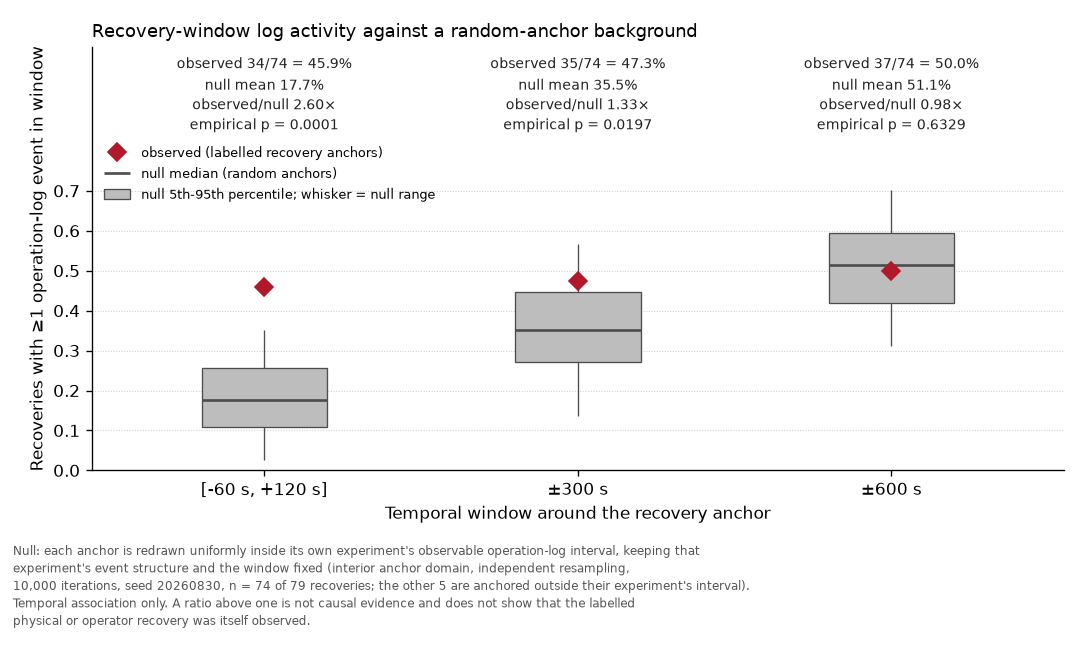

In [9]:
from IPython.display import Image

Image(filename=str(ROOT / "results" / "figures" / "recovery_activity_vs_background.png"))

## 7. Background / null comparison

The coverage metric cannot say whether the activity it counts is *unusual*. Here each labelled anchor is replaced by a random anchor drawn inside the same experiment's own observable operation-log interval, holding the window and that experiment's event density fixed. Timestamps are never pooled across experiments. Construction, inclusion rules, and sensitivity variants are in `METHODOLOGY.md` section 7.

Five of the 79 included recoveries are anchored outside their experiment's logged interval altogether, so no window of any width can match them. They are unanswerable for the coverage question rather than negative answers to it, and they sit outside the comparison.

print(f"Seed: {background['seed']}  Iterations: {background['iterations']:,}")
print(
    "Primary variant:",
    background["primary_variant"]["anchor_domain_mode"],
    "anchor domain,",
    background["primary_variant"]["resampling"],
    "resampling",
)
print(
    "Anchored outside the observable log interval:",
    inclusion["anchored_outside_observable_log_interval"],
    "of",
    inclusion["included_with_operation_log"],
)
print()
print("window	observed	background	ratio	empirical_p")
for entry in background["windows"]:
    window = f"-{entry['pre_window_seconds']}/+{entry['post_window_seconds']}s"
    print(
        f"{window}	"
        f"{entry['observed_matched']}/{entry['analysed_recoveries']} = {entry['observed_fraction']:.2%}	"
        f"{entry['expected_fraction']:.2%}		"
        f"{entry['ratio_observed_over_expected']:.2f}x	"
        f"{entry['empirical_p_value']:.4f}"
    ) A background ratio above one is temporal association only, and the null holds the event structure fixed: it tests where the labels sit relative to that log, not whether the log is a faithful record of the plant.